# 转化漏斗分析

**分析目标**：用户从"浏览"到"购买"的路径上，在哪一步流失最严重？

**口径**：漏斗的每一层用去重用户数（UV），不是行为次数——漏斗衡量的是"人"的流转。

**漏斗路径**：浏览(pv) → 兴趣(收藏/加购) → 购买(buy)

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, URL

# 中文字体（Windows 用微软雅黑）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 连数据库（密码含 @，必须用 URL.create）
url = URL.create(
    "mysql+pymysql",
    username="root",
    password=os.environ["MYSQL_PASSWORD"],
    host="localhost",
    port=3306,
    database="taobao_analysis",
    query={"charset": "utf8mb4"},
)
engine = create_engine(url)
print("连接成功 ✅")

连接成功 ✅


## 第 1 步：各行为类型的去重用户数

In [2]:
uv = pd.read_sql(
    """
    SELECT behavior_type,
           COUNT(DISTINCT user_id) AS uv,
           COUNT(*) AS cnt
    FROM user_behavior
    GROUP BY behavior_type
    ORDER BY uv DESC
    """,
    con=engine,
)
uv

,behavior_type,uv,cnt
0,pv,980,89709
1,cart,723,5446
2,buy,671,2101
3,fav,363,2744


## 第 2 步：兴趣层（收藏 + 加购的并集，去重）

In [3]:
interest = pd.read_sql(
    """
    SELECT COUNT(DISTINCT user_id) AS interest_uv
    FROM user_behavior
    WHERE behavior_type IN ('fav', 'cart')
    """,
    con=engine,
)
interest

,interest_uv
0,841


## 第 3 步：组装漏斗 + 计算转化率

两种转化率都要算：
- **整体转化率**：每一层 ÷ 第一层（衡量"从头走到这"）
- **环节转化率**：每一层 ÷ 上一层（衡量"这一步流失多少"）

In [4]:
pv_uv = uv.loc[uv["behavior_type"] == "pv", "uv"].iloc[0]
buy_uv = uv.loc[uv["behavior_type"] == "buy", "uv"].iloc[0]
interest_uv = interest["interest_uv"].iloc[0]

funnel = pd.DataFrame({
    "阶段": ["浏览 pv", "兴趣 fav/cart", "购买 buy"],
    "uv": [pv_uv, interest_uv, buy_uv],
})
funnel["整体转化率"] = (funnel["uv"] / pv_uv).round(3)
funnel["环节转化率"] = (funnel["uv"] / funnel["uv"].shift(1)).round(3)
funnel

,阶段,uv,整体转化率,环节转化率
0,浏览 pv,980,1.000,NaN
1,兴趣 fav/cart,841,0.858,0.858
2,购买 buy,671,0.685,0.798


## 第 4 步：画漏斗图

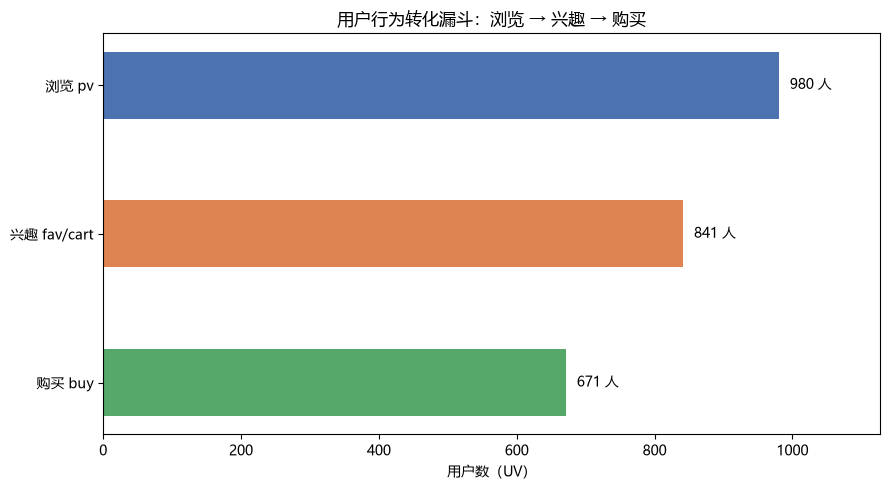

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = funnel["阶段"]
vals = funnel["uv"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

bars = ax.barh(labels[::-1], vals[::-1], color=colors[::-1], height=0.45)
ax.bar_label(bars, fmt="%d 人", padding=8)
ax.set_xlabel("用户数（UV）")
ax.set_title("用户行为转化漏斗：浏览 → 兴趣 → 购买")
ax.set_xlim(0, max(vals) * 1.15)
plt.tight_layout()
plt.savefig(r"C:\Users\wukeyu31434\data-analyst-projects\taobao-user-behavior-analysis\reports\funnel_chart.png", dpi=150)
plt.show()

## 第 5 步：子路径转化率（收藏→购买 vs 加购→购买）

两条兴趣路径哪个更接近购买？

In [6]:
paths = pd.read_sql(
    """
    SELECT
      COUNT(DISTINCT bt.user_id) / COUNT(DISTINCT ft.user_id) AS fav_to_buy,
      COUNT(DISTINCT bt2.user_id) / COUNT(DISTINCT ct.user_id) AS cart_to_buy
    FROM
      (SELECT DISTINCT user_id FROM user_behavior WHERE behavior_type='fav') ft
      LEFT JOIN (SELECT DISTINCT user_id FROM user_behavior WHERE behavior_type='buy') bt
        ON ft.user_id = bt.user_id,
      (SELECT DISTINCT user_id FROM user_behavior WHERE behavior_type='cart') ct
      LEFT JOIN (SELECT DISTINCT user_id FROM user_behavior WHERE behavior_type='buy') bt2
        ON ct.user_id = bt2.user_id
    """,
    con=engine,
)
paths.round(3)

,fav_to_buy,cart_to_buy
0,0.736,0.729


## 第 6 步：数据质量检查：3 个无浏览用户

总用户 983 人，但 pv 用户只有 980 人——3 个用户从未浏览、却直接收藏/加购/购买了。

In [7]:
ghost = pd.read_sql(
    """
    SELECT user_id, behavior_type, COUNT(*) AS cnt
    FROM user_behavior
    WHERE user_id NOT IN (
        SELECT DISTINCT user_id FROM user_behavior WHERE behavior_type = 'pv'
    )
    GROUP BY user_id, behavior_type
    """,
    con=engine,
)
ghost

,user_id,behavior_type,cnt
0,1001148,fav,5
1,1001148,cart,3
2,1001148,buy,1
3,1003646,fav,17
4,1003646,cart,1
5,1003767,buy,3
6,1003767,cart,5


## 报告

完整业务解读（流失定位、可执行建议、口径声明）见 `reports/funnel_insights.md`。